# Web Scraping Data Analysis

**Student Name:** Pei Zheng

**Date:** 10/26/2025

**Website Scraped:** https://arxiv.org/search/

## Project Overview

- Data source: arXiv search HTML (no API)
- Fields collected: `title`, `authors`, `abstract`, `categories`, `submission_date`
- Goal: Explore recent research patterns from arXiv search results for “*AI*”.

## 1. Import Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
import re
from collections import Counter

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Data

In [4]:
# Load your scraped data
# Modify the filename to match your saved data file
df = pd.read_csv("data/arxiv_AI_20251026.csv")

## 3. Data Overview

In [5]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head(5)

First 5 rows of the dataset:


,title,authors,abstract,categories,submission_date
0,"Real Deep Research forAI, Robotics and Beyond",Xueyan Zou; Jianglong Ye; Hao Zhang; Xiaoyu Xiang; Mingyu Ding; Zhaojing Yang; Yong Jae Lee; Zhu...,"With the rapid growth of research in AI and robotics now producing over 10,000 papers annually i...",Artificial Intelligence (cs.AI) ; Computation and Language (cs.CL); Computer Vision and Pattern ...,23 Oct 2025
1,AI-Enabled Digital Twins for Next-Generation Networks: Forecasting Traffic and Resource Manageme...,John Sengendo; Fabrizio Granelli,"…However, for Digital Twin Networks (DTNs) to meet the challenges faced by operators especially ...",Networking and Internet Architecture (cs.NI),23 Oct 2025
2,Out-of-distribution Tests Reveal Compositionality in Chess Transformers,Anna Mészáros; Patrik Reizinger; Ferenc Huszár,…Chess) - a variant of chess where starting positions of pieces are randomized. We found that wh...,Machine Learning (cs.LG),23 Oct 2025
3,A Use-Case Specific Dataset for Measuring Dimensions of Responsible Performance in LLM-generated...,Alicia Sagae; Chia-Jung Lee; Sandeep Avula; Brandon Dang; Vanessa Murdock,Current methods for evaluating large language models (LLMs) typically focus on high-level tasks ...,Computation and Language (cs.CL) ; Artificial Intelligence (cs.AI),23 Oct 2025
4,Empathic Prompting: Non-Verbal Context Integration for Multimodal LLM Conversations,Lorenzo Stacchio; Andrea Ubaldi; Alessandro Galdelli; Maurizio Mauri; Emanuele Frontoni; Andrea ...,"We present Empathic Prompting, a novel framework for multimodal human- AI interaction that enric...",Human-Computer Interaction (cs.HC) ; Artificial Intelligence (cs.AI); Computation and Language (...,23 Oct 2025


In [6]:
# Basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            60 non-null     object
 1   authors          60 non-null     object
 2   abstract         60 non-null     object
 3   categories       60 non-null     object
 4   submission_date  60 non-null     object
dtypes: object(5)
memory usage: 2.5+ KB


In [7]:
# Statistical summary
print(df.describe(include='all'))

                                                title  \
count                                              60   
unique                                             60   
top     Real Deep Research forAI, Robotics and Beyond   
freq                                                1   

                                                                                                    authors  \
count                                                                                                    60   
unique                                                                                                   60   
top     Xueyan Zou; Jianglong Ye; Hao Zhang; Xiaoyu Xiang; Mingyu Ding; Zhaojing Yang; Yong Jae Lee; Zhu...   
freq                                                                                                      1   

                                                                                                   abstract  \
count                                          

## 4. Data Cleaning

In [8]:
# Check for missing values
print(df.isna().sum())

title              0
authors            0
abstract           0
categories         0
submission_date    0
dtype: int64


In [9]:
# Data cleaning steps
# TODO: Add your data cleaning code here

# - Remove duplicates
df.drop_duplicates(subset=["title"], inplace=True)

# Ensure correct dtypes and simple text normalization
for col in ['title','authors','abstract','categories','submission_date']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

print("Cleaned data shape:", df.shape)

Cleaned data shape: (60, 5)


## 5. Exploratory Data Analysis

In [ ]:
# TODO: Add your analysis code here

# Word frequency in titles
# Combine all titles into one string
text = " ".join(df['title'].dropna().tolist()).lower()

# Tokenize words (only alphabetic words with >=4 letters)
words = re.findall(r'\b[a-zA-Z]{4,}\b', text)

# Count word frequencies
word_counts = Counter(words)

# Top 20 most frequent words
top_words = pd.DataFrame(word_counts.most_common(5), columns=['word', 'count'])
print("Top 5 frequent words in titles:")
print(top_words)

Top 5 frequent words in titles:
       word  count
0    models      9
1  learning      8
2  language      8
3      text      6
4     based      6


In [16]:
# Plotting the top categories
# Split categories by ';' and flatten
category_series = df['categories'].dropna().str.split(";")
category_list = [c.strip() for sublist in category_series for c in sublist]

# Count frequency
cat_counts = pd.Series(category_list).value_counts().reset_index()
cat_counts.columns = ['category', 'count']

print("Top 5 most frequent categories:")
print(cat_counts.head(5))

Top 5 most frequent categories:
                                          category  count
0                  Artificial Intelligence (cs.AI)     34
1                         Machine Learning (cs.LG)     16
2                 Computation and Language (cs.CL)     14
3  Computer Vision and Pattern Recognition (cs.CV)     10
4                Cryptography and Security (cs.CR)      9


In [18]:
# Count number of authors for each paper
author_counts = df['authors'].apply(lambda x: len(str(x).split(";")) if pd.notna(x) else 0)

# Frequency of author counts
author_freq = author_counts.value_counts().sort_values(ascending=False)

print("Frequency of author counts:")
print(author_freq)

Frequency of author counts:
authors
4     12
6     10
2      9
3      6
8      6
5      5
1      4
15     2
10     1
20     1
25     1
7      1
9      1
13     1
Name: count, dtype: int64


## 6. Data Visualization

### Visualization 1: High Frequency Words in Titles

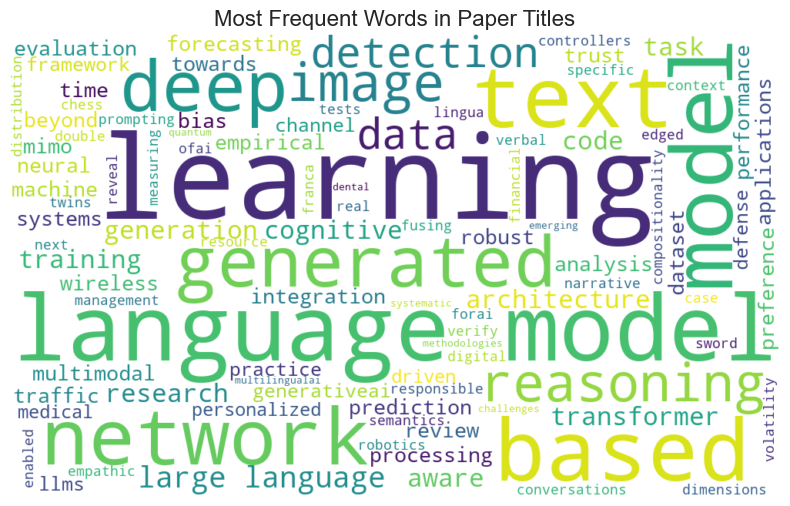

In [ ]:
# Create your first visualization
# TODO: Replace with your actual visualization code
# !pip install wordcloud
from wordcloud import WordCloud
wordcloud = WordCloud(width=1000, height=600, background_color="white",
                      max_words=100, colormap='viridis').generate(" ".join(words))

plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequent Words in Paper Titles", fontsize=16)
plt.show()

### Visualization 2: Top 10 Categories

/var/folders/49/0rxntbsn5hs0bhv6nxbm70700000gn/T/ipykernel_85835/456911650.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='category', x='count', data=cat_counts.head(10), palette="crest")


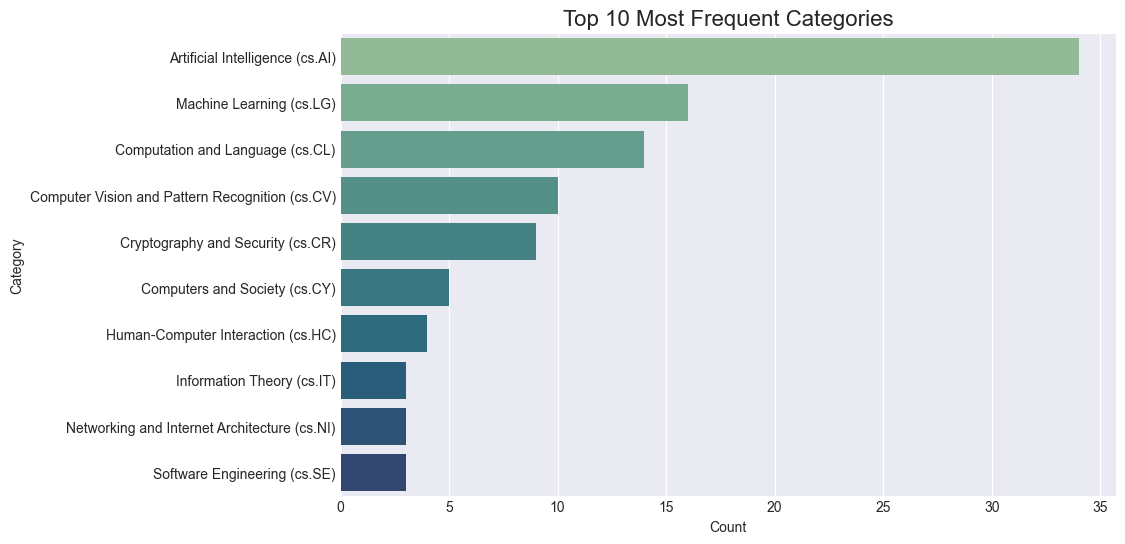

In [23]:
# Create your second visualization
# TODO: Replace with your actual visualization code
plt.figure(figsize=(10,6))
sns.barplot(y='category', x='count', data=cat_counts.head(10), palette="crest")
plt.title("Top 10 Most Frequent Categories", fontsize=16)
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

### Visualization 3: Distribution of Author Counts per Paper

/var/folders/49/0rxntbsn5hs0bhv6nxbm70700000gn/T/ipykernel_85835/344718022.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=author_freq.index, y=author_freq.values, palette="viridis")


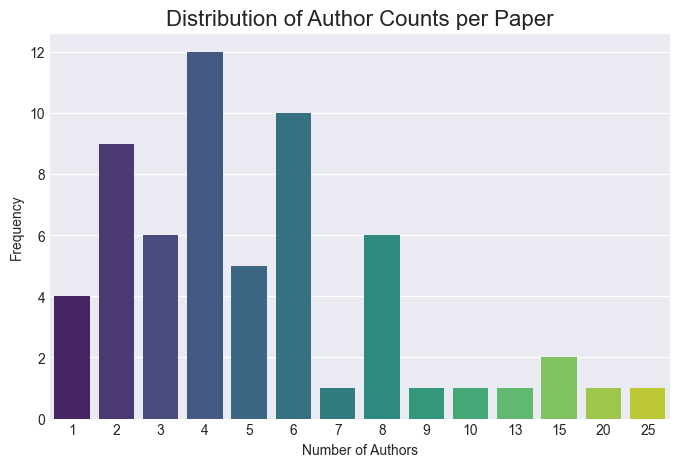

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(x=author_freq.index, y=author_freq.values, palette="viridis")
plt.title("Distribution of Author Counts per Paper", fontsize=16)
plt.xlabel("Number of Authors")
plt.ylabel("Frequency")
plt.show()

## 7. Key Findings

Based on the analysis above, here are the key findings:

1. **Finding 1:**   
The most frequent words appearing in paper titles are “models,” “learning,” “language,” “text,” and “based.”  
This indicates that the recent arXiv publications under the “AI” keyword are heavily focused on machine learning models, language-based systems, and text-related AI applications such as large language models and NLP frameworks.

2. **Finding 2:**   
The most common research categories are Artificial Intelligence (cs.AI), Machine Learning (cs.LG), and Computation and Language (cs.CL).  
This pattern highlights that AI research today is highly concentrated in core algorithmic development, ML model improvement, and language-based AI systems, showing strong overlaps between AI, ML, and LLM-related fields.

3. **Finding 3:**    
The author count distribution shows that most papers are written by 3–6 authors, while a few large collaborations exceed 10+ authors.  
This suggests that current AI research tends to involve small-to-medium research teams, possibly reflecting interdisciplinary cooperation between academic and industry partners but not large consortium-style efforts.

## 8. Interpretation and Discussion

[Write 2-3 paragraphs interpreting your findings. Consider:]

- What patterns did you discover in the data?
- What surprised you about the results?
- How might these findings be relevant to social science research?
- What are the limitations of your analysis?
- What additional data or analysis would be valuable?

**Paragraph 1:** [Discuss main patterns and insights]     
The dataset reveals several clear patterns in current AI research trends on arXiv. The most common words in paper titles — models, learning, language, text, based — highlight a strong focus on large language models and text-based machine learning systems. This aligns with the ongoing surge of interest in generative AI, multimodal learning, and model architecture optimization. The dominance of categories such as Artificial Intelligence (cs.AI), Machine Learning (cs.LG), and Computation and Language (cs.CL) suggests that a significant portion of recent research continues to revolve around developing more capable and interpretable models, while maintaining strong ties to natural language understanding and computational linguistics.

**Paragraph 2:** [Discuss implications and relevance]   
These findings are particularly relevant to social science and interdisciplinary research. The growing emphasis on “language” and “interaction” within AI research signals a convergence between computational methods and human-centered applications — such as education, ethics, and communication. The moderate author collaboration range (mostly 3–6 per paper) reflects the structure of modern AI research teams: cross-institutional yet compact, often combining expertise in computer science, data analysis, and cognitive or social theory. This collaborative model may influence how AI research impacts social systems and policy design, as well as how AI knowledge disseminates across global academic networks.

**Paragraph 3:** [Discuss limitations and future work]   
However, there are notable limitations. The dataset includes only 60 papers, which is not sufficient to generalize broad trends in AI research. A larger and more longitudinal dataset — for instance, covering multiple months or years — would allow for time-series analysis of topic evolution and collaboration networks. Future work could expand the scope by integrating additional metadata such as citation counts, institutional affiliations, and geographic locations to uncover deeper patterns in global AI research dynamics and their implications for society.

## 9. Data Dictionary

| Column Name | Data Type | Description | Example |
|-------------|-----------|-------------|---------|
| title | string | Paper title | "Real Deep Research forAI, Robotics and Beyond" |
| authors | string | Paper Authors | Anna Mészáros; Patrik Reizinger; Ferenc Huszár |
| abstract | string | Abstract text | With the rapid growth of research in AI and robotics now producing over 10,000 papers annually i... |
| categories | string | Paper categories | Computation and Language (cs.CL) ; Artificial Intelligence (cs.AI) |
| submission_date | datetime | Paper submission date | 23 Oct 2025 |

## 10. Technical Challenges and Solutions

### Challenges Encountered:

1. **Challenge 1:** Pagination and Record Limitation
   - **Solution:**   
   Initially, the scraper was unable to retrieve the desired 60 records because it only collected results from the first page. To resolve this, an automated pagination mechanism was implemented in the code, allowing the scraper to iterate through multiple result pages until reaching the target number of records.

2. **Challenge 2:** Missing Metadata Fields (Categories and Submission Dates)
   - **Solution:**   
   At first, the scraped dataset showed empty values for categories and submission_date because the scraper was pulling data only from the search results page, which did not contain these details. The issue was solved by modifying the script to visit each paper’s detailed page (the /abs/ page) and extract the category and submission date directly from the article metadata.

### Ethical Considerations:

- Checked robots.txt and used a custom User-Agent.
- Applied a 1.2-second delay between page requests.
- Collected only public metadata for research/educational purposes.

## 11. Conclusion
In this project, I successfully built a functional web scraper to collect recent AI-related research papers from arXiv. The scraper extracted key information including titles, authors, abstracts, categories, and submission dates, while implementing respectful scraping practices such as request delays and page iteration. After data collection, I performed exploratory analysis and visualization to uncover trends in AI research — identifying dominant themes, research fields, and collaboration patterns among authors. Despite the dataset’s limited size, this project demonstrated the full pipeline of data acquisition, cleaning, and analysis using real-world web data, providing a solid foundation for larger-scale research trend analysis in the future.

## References

- Website scraped: https://arxiv.org/search/
- Date of data collection: 10/26/2025
- Any additional references or resources used

In [25]:
# Save the cleaned dataset for future use
df.to_csv('data/cleaned_data.csv', index=False)
print("Cleaned data saved to 'data/cleaned_data.csv'")

Cleaned data saved to 'data/cleaned_data.csv'
